In [21]:
pip install librosa soundfile numpy pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [33]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

import librosa
import soundfile as sf

import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# Data Augmentation

### add_noise:

In [ ]:
def add_noise(y, noise_level=0.005):
    noise = np.random.randn(len(y))
    return y + noise_level * noise


### change_pitch:

In [ ]:
def change_pitch(y, sr, n_steps=2):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)


### change_speed:

In [ ]:
def change_speed(y, rate=1.1):
    return librosa.effects.time_stretch(y, rate=rate)


### A function that returns several versions of the same recording:

In [ ]:
def augment_audio(y, sr):
    augmented = []

    augmented.append(y)  # The original
    augmented.append(add_noise(y))
    augmented.append(change_pitch(y, sr, n_steps=2))
    augmented.append(change_speed(y, rate=1.1))

    return augmented


## Audio-to-Feature Vector Transformation and Data Augmentation

In [ ]:
# def extract_features_with_augmentation(wav_path, sr=16000):
#     y, _ = librosa.load(wav_path, sr=sr)

#     augmented_signals = augment_audio(y, sr)

#     features = []
#     for sig in augmented_signals:
#         mfcc = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=40).mean(axis=1)
#         chroma = librosa.feature.chroma_stft(
#             S=np.abs(librosa.stft(sig)), sr=sr
#         ).mean(axis=1)
#         mel = librosa.feature.melspectrogram(y=sig, sr=sr, n_mels=128)
#         mel = librosa.power_to_db(mel).mean(axis=1)

#         feat = np.concatenate([mfcc, chroma, mel])
#         features.append(feat)

#     return features


### Statistics  (not working yet - ther's no db )

import librosa
import os

path = "data/clean_audio/db"
durations = []

for f in os.listdir(path):
    if f.endswith(".wav"):
        y, sr = librosa.load(os.path.join(path, f), sr=None)
        durations.append(len(y) / sr)

print("Min duration (sec):", min(durations))
print("Avg duration (sec):", sum(durations) / len(durations))
print("Max duration (sec):", max(durations))
print("Total files:", len(durations))


## RAVDESS augmented dataset

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import pandas as pd

OUTPUT_DIR = "data\raw_audio\ravdess\augmentation train record"

TARGET_SR = 16000

os.makedirs(OUTPUT_DIR, exist_ok=True)


def add_noise(y, noise_level=0.005):
    noise = np.random.randn(len(y))
    return y + noise_level * noise

def change_pitch(y, sr, n_steps=2):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def change_speed(y, rate=1.1):
    return librosa.effects.time_stretch(y, rate=rate)



def augment_and_save_train_audio(train_df, sr=TARGET_SR):
    total_written = 0

    for _, row in train_df.iterrows():
        # Load original audio
        y, _ = librosa.load(row.filepath, sr=sr)

        augmented_versions = {
            "orig": y,
            "noise": add_noise(y),
            "pitch": change_pitch(y, sr),
            "speed": change_speed(y)
        }

        for aug_type, signal in augmented_versions.items():
            out_filename = f"{row.record_id}_{aug_type}.wav"
            out_path = os.path.join(OUTPUT_DIR, out_filename)

            sf.write(out_path, signal, sr)
            total_written += 1

    print(f"Augmentation completed. Total files written: {total_written}")



if __name__ == "__main__":
    
    if "train_df" not in globals():
        raise RuntimeError(
            "train_df is not defined.\n"
        )

    augment_and_save_train_audio(train_df)


## RAVDESS dataset split

In [1]:
import librosa.display
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=data, sr=sr)
ipd.Audio(data,rate=sr)

NameError: name 'plt' is not defined

### Validation of actors number before splitting the data

In [23]:
import os
import random

base_path = "data/raw_audio/ravdess/original record"
actors = sorted(os.listdir(base_path))

print(len(actors))  

24


### spliting the data into train, test and validation sets

In [24]:
train_actors = actors[:17] #take first 17 actors
val_actors   = actors[17:21] #take from 17 to 21 actors
test_actors  = actors[21:] #take from 21 to last actors

print("Train actors:", train_actors)
print("Val actors:", val_actors)
print("Test actors:", test_actors)


Train actors: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17']
Val actors: ['Actor_18', 'Actor_19', 'Actor_20', 'Actor_21']
Test actors: ['Actor_22', 'Actor_23', 'Actor_24']


### matcing the new datasets into dataframes

In [ ]:
import os
import pandas as pd

base_path = "data/raw_audio/ravdess/original record"
rows = []

emotion_map = {
    1: "neutral",
    3: "happy",
    4: "sad",
    5: "angry"
}

allowed_emotions = emotion_map.keys()

for actor in os.listdir(base_path):
    actor_path = os.path.join(base_path, actor)

    if not os.path.isdir(actor_path):
        continue

    actor_num = int(actor.split("_")[1])
    gender = "female" if actor_num % 2 == 0 else "male"

    for fname in os.listdir(actor_path):
        if not fname.endswith(".wav"):
            continue

        name = fname.replace(".wav", "")
        parts = name.split("-")

        emotion_code = int(parts[2])

        if emotion_code not in allowed_emotions:
            continue

        emotion_text = emotion_map[emotion_code]

        rows.append({
            "filepath": os.path.join(actor_path, fname),
            "actor_id": actor,
            "actor_num": actor_num,
            "gender": gender,
            "emotion_code": emotion_code,
            "emotion": emotion_text,
            "emotion_gender": f"{emotion_text}_{gender}",
            "record_id": name
        })

df = pd.DataFrame(rows)


In [26]:
train_df = df[df.actor_id.isin(train_actors)]
val_df   = df[df.actor_id.isin(val_actors)]
test_df  = df[df.actor_id.isin(test_actors)]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

print("Total samples:", len(df))
print("Emotion distribution:")
print(df.emotion.value_counts().sort_index())


(476, 8)
(112, 8)
(84, 8)
Total samples: 672
Emotion distribution:
emotion
angry      192
happy      192
neutral     96
sad        192
Name: count, dtype: int64


In [27]:
def load_audio(filepath):
    X, sr = librosa.load(filepath, sr=None)
    if X.ndim == 2: #if its stereo - make it mono
        X = np.mean(X, axis=1)
    return X, sr


In [28]:
def extract_features(filepath): #bulid visualisation features
    X, sr = load_audio(filepath)

    mfcc = librosa.feature.mfcc(y=X, sr=sr, n_mfcc=40).mean(axis=1)
    chroma = librosa.feature.chroma_stft(
        S=np.abs(librosa.stft(X)), sr=sr
    ).mean(axis=1)
    mel = librosa.feature.melspectrogram(y=X, sr=sr, n_mels=128)
    mel = librosa.power_to_db(mel).mean(axis=1)

    return np.concatenate([mfcc, chroma, mel])


In [29]:
def build_dataset(df):
    X, y = [], [] # X - features, y - labels (emotions + gender)

    for _, row in df.iterrows():
        try:
            feats = extract_features(row.filepath)
            X.append(feats)
            y.append(row.emotion)
        except Exception as e:
            print("Failed:", row.filepath, e)

    return np.array(X), np.array(y)


X_train, y_train = build_dataset(train_df)
X_val, y_val     = build_dataset(val_df)
X_test, y_test   = build_dataset(test_df)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(476, 180) (476,)
(112, 180) (112,)
(84, 180) (84,)


In [30]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion_gender"])
y_val   = encoder.transform(val_df["emotion_gender"])
y_test  = encoder.transform(test_df["emotion_gender"])



In [31]:
scaler = StandardScaler() #each visualisation has its own scaler

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


### check the disterbution of the data before modeling

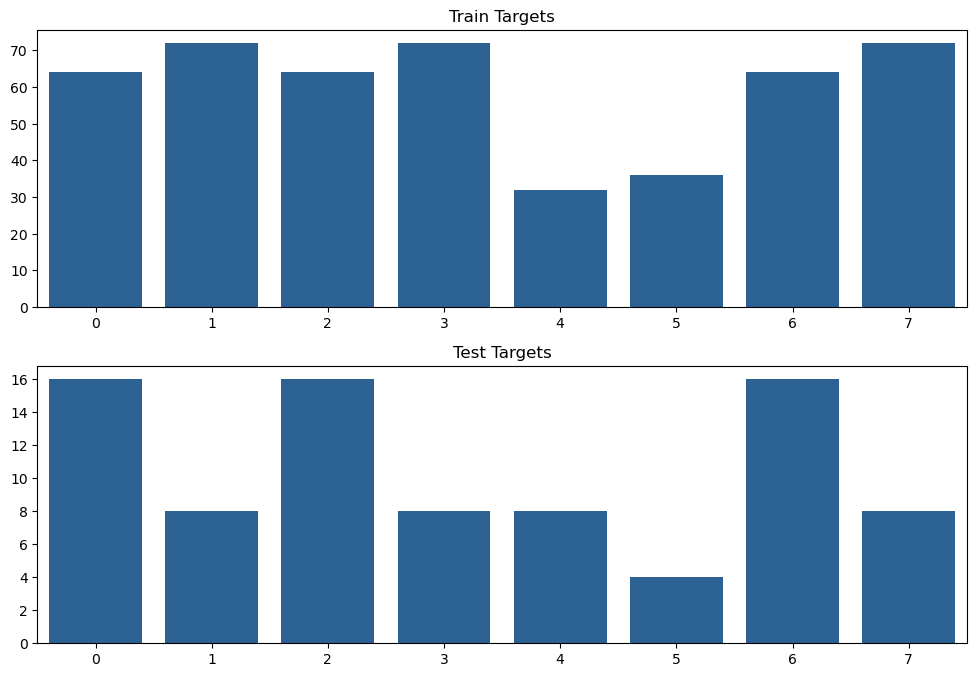

In [34]:
fig = plt.figure(figsize=(10, 10)) 

ax_train = fig.add_subplot(311)
train_vals = np.unique(y_train, return_counts=True)
sns.barplot(x=train_vals[0], y=train_vals[1], color='#1b62a5')
ax_train.set_title("Train Targets")

ax_test = fig.add_subplot(312)
test_vals = np.unique(y_test, return_counts=True)
sns.barplot(x=test_vals[0], y=test_vals[1], color='#1b62a5')
ax_test.set_title("Test Targets")

plt.tight_layout()
plt.show()
